In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

In [12]:
df=pd.read_csv('github_candidates_1.csv')
df.head()

,username,public_repos,total_stars,total_forks,commits_12m,dominant_language,has_cicd
0,octocat,8,20827,162625,0,Ruby,0
1,torvalds,11,226289,61144,95,C,0
2,kennethreitz,74,2130,300,0,Python,1
3,mojombo,66,10362,6758,0,Ruby,0
4,defunkt,107,8654,9834,65,JavaScript,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   username           30 non-null     object
 1   public_repos       30 non-null     int64 
 2   total_stars        30 non-null     int64 
 3   total_forks        30 non-null     int64 
 4   commits_12m        30 non-null     int64 
 5   dominant_language  30 non-null     object
 6   has_cicd           30 non-null     int64 
dtypes: int64(5), object(2)
memory usage: 1.8+ KB


In [14]:
(df == 0).sum()

username              0
public_repos          0
total_stars           0
total_forks           0
commits_12m          20
dominant_language     0
has_cicd             20
dtype: int64

In [18]:
X=df.drop('username', axis=1)
X=X.drop('dominant_language', axis=1).join(pd.get_dummies(X['dominant_language'], drop_first=True).astype(int))
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [19]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24 entries, 28 to 6
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   public_repos  24 non-null     int64
 1   total_stars   24 non-null     int64
 2   total_forks   24 non-null     int64
 3   commits_12m   24 non-null     int64
 4   has_cicd      24 non-null     int64
 5   C             24 non-null     int64
 6   Go            24 non-null     int64
 7   HTML          24 non-null     int64
 8   Java          24 non-null     int64
 9   JavaScript    24 non-null     int64
 10  PHP           24 non-null     int64
 11  Python        24 non-null     int64
 12  Ruby          24 non-null     int64
 13  Rust          24 non-null     int64
 14  TypeScript    24 non-null     int64
dtypes: int64(15)
memory usage: 3.0 KB


In [23]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),   
    ('kmeans', KMeans(n_clusters=2, random_state=42))
])
pipeline.fit(X_train)
y_pred = pipeline.predict(X_test)
print(y_pred)

[1 1 0 0 0 0]


d:\nihal\New folder\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [24]:
from sklearn.metrics import silhouette_score


score = silhouette_score(X, pipeline.predict(X))
print("Silhouette Score:", score)

Silhouette Score: 0.0026537332951873677


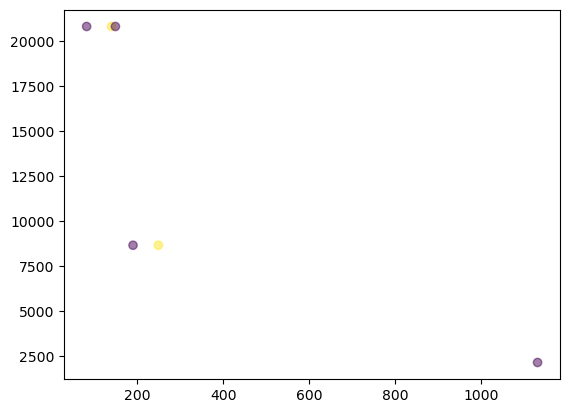

In [26]:
X_test_array = X_test.to_numpy()

plt.scatter(X_test_array[:, 0], X_test_array[:, 1], c=y_pred, alpha=0.5)
plt.show()